# Phase 1: Experiment EDA

Goal: validate the randomized advertising experiment before building uplift models.

By the end of this notebook, we should know:

- How many users are in the experiment
- Whether treatment/control groups are the right size
- Baseline conversion rates by treatment group
- Average treatment effect (ATE)
- Whether randomized groups are balanced on user/context features
- Whether the data is clean enough for Phase 2 uplift modeling

## 1. Setup

We use DuckDB to query the raw CSV directly. This avoids loading the full 3GB file into pandas memory.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Works whether VS Code starts the notebook from the project root or notebooks/.
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "data").exists() else cwd.parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "criteo-uplift-v2.1.csv"

assert DATA_PATH.exists(), f"Missing data file: {DATA_PATH}"
DATA_PATH

WindowsPath('c:/Users/roder/OneDrive/Desktop/Causal Project/causal-impact-estimation/data/raw/criteo-uplift-v2.1.csv')

In [3]:
con = duckdb.connect(database=":memory:")

con.execute(f"""
    create or replace view experiment as
    select *
    from read_csv_auto('{DATA_PATH.as_posix()}', sample_size=100000)
""")

con.sql("select * from experiment limit 5").df()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.6164,10.0597,8.9764,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
1,12.6164,10.0597,9.0027,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
2,12.6164,10.0597,8.9648,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
3,12.6164,10.0597,9.0028,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
4,12.6164,10.0597,9.0380,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0


## 2. Schema and Experiment Size

In [4]:
schema = con.sql("describe experiment").df()
schema

,column_name,column_type,null,key,default,extra
0,f0,DOUBLE,YES,None,None,None
1,f1,DOUBLE,YES,None,None,None
2,f2,DOUBLE,YES,None,None,None
3,f3,DOUBLE,YES,None,None,None
4,f4,DOUBLE,YES,None,None,None
5,f5,DOUBLE,YES,None,None,None
6,f6,DOUBLE,YES,None,None,None
7,f7,DOUBLE,YES,None,None,None
8,f8,DOUBLE,YES,None,None,None
9,f9,DOUBLE,YES,None,None,None


In [5]:
columns = schema["column_name"].tolist()
feature_cols = [c for c in columns if c.startswith("f")]

TREATMENT_COL = "treatment"
OUTCOME_COL = "conversion"
VISIT_COL = "visit"
EXPOSURE_COL = "exposure"

print(f"Columns: {len(columns)}")
print(f"Feature columns: {feature_cols}")

Columns: 16
Feature columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']


In [6]:
con.sql("select count(*) as users from experiment").df()

,users
0,13979592


## 3. Treatment and Outcome Summary

This is the core product analytics table: treatment size, control size, and raw conversion rates.

In [7]:
group_summary = con.sql(f"""
    select
        {TREATMENT_COL} as treatment,
        count(*) as users,
        count(*) * 1.0 / sum(count(*)) over () as user_share,
        avg({OUTCOME_COL}) as conversion_rate,
        avg({VISIT_COL}) as visit_rate,
        avg({EXPOSURE_COL}) as exposure_rate
    from experiment
    group by 1
    order by 1
""").df()

group_summary

,treatment,users,user_share,conversion_rate,visit_rate,exposure_rate
0,0,2096937,0.1500,0.0019,0.0382,0.0000
1,1,11882655,0.8500,0.0031,0.0485,0.0360


In [9]:
treatment_stats = group_summary.set_index("treatment")

control_cr = treatment_stats.loc[0, "conversion_rate"]
treatment_cr = treatment_stats.loc[1, "conversion_rate"]

ate = treatment_cr - control_cr
relative_lift = ate / control_cr

pd.DataFrame({
    "metric": [
        "control_conversion_rate",
        "treatment_conversion_rate",
        "ate_percentage_points",
        "relative_lift",
    ],
    "value": [control_cr, treatment_cr, ate, relative_lift],
})

,metric,value
0,control_conversion_rate,0.0019
1,treatment_conversion_rate,0.0031
2,ate_percentage_points,0.0012
3,relative_lift,0.5945


In [10]:
# Difference-in-proportions confidence interval for ATE.
n_t = treatment_stats.loc[1, "users"]
n_c = treatment_stats.loc[0, "users"]
p_t = treatment_cr
p_c = control_cr

se = np.sqrt((p_t * (1 - p_t) / n_t) + (p_c * (1 - p_c) / n_c))
ci_low = ate - 1.96 * se
ci_high = ate + 1.96 * se
z_score = ate / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))

pd.DataFrame({
    "ate": [ate],
    "std_error": [se],
    "ci_low": [ci_low],
    "ci_high": [ci_high],
    "p_value": [p_value],
})

,ate,std_error,ci_low,ci_high,p_value
0,0.0012,0.0000,0.0011,0.0012,0.0000


### Interpretation
Treatment is associated with higher conversion. The estimated average treatment effect is approximately 0.12 percentage points, meaning the treated group converted about 0.12 percentage points higher than the control group.

In relative terms, this represents a 59.45% lift over the control conversion rate. Although the absolute lift is small, the relative lift is large because the baseline conversion rate is low, making the result potentially meaningful for promotion targeting at scale.

## 4. Missing Values

In [14]:
missing_exprs = ",\n        ".join([
    f"sum(case when {col} is null then 1 else 0 end) as {col}_missing"
    for col in columns
])

missing_wide = con.sql(f"""
    select
        count(*) as users,
        {missing_exprs}
    from experiment
""").df()

missing = (
    missing_wide.drop(columns="users")
    .T
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

missing["column"] = missing["column"].str.replace("_missing", "", regex=False)
missing["missing_rate"] = missing["missing_count"] / missing_wide.loc[0, "users"]
missing.sort_values("missing_rate", ascending=False)

,column,missing_count,missing_rate
0,f0,0.0000,0.0000
1,f1,0.0000,0.0000
2,f2,0.0000,0.0000
3,f3,0.0000,0.0000
4,f4,0.0000,0.0000
5,f5,0.0000,0.0000
6,f6,0.0000,0.0000
7,f7,0.0000,0.0000
8,f8,0.0000,0.0000
9,f9,0.0000,0.0000


## 5. Randomization Balance Check

For a randomized experiment, pre-treatment features should look similar across treatment and control.

We use standardized mean difference (SMD):

`SMD = (mean_treatment - mean_control) / pooled_standard_deviation`

Rule of thumb: `abs(SMD) < 0.1` is usually considered balanced.

In [15]:
balance_rows = []

for col in feature_cols:
    stats_by_group = con.sql(f"""
        select
            {TREATMENT_COL} as treatment,
            avg({col}) as mean_value,
            stddev_samp({col}) as sd_value
        from experiment
        group by 1
        order by 1
    """).df().set_index("treatment")

    mean_c = stats_by_group.loc[0, "mean_value"]
    mean_t = stats_by_group.loc[1, "mean_value"]
    sd_c = stats_by_group.loc[0, "sd_value"]
    sd_t = stats_by_group.loc[1, "sd_value"]
    pooled_sd = np.sqrt((sd_t ** 2 + sd_c ** 2) / 2)
    smd = (mean_t - mean_c) / pooled_sd if pooled_sd else np.nan

    balance_rows.append({
        "feature": col,
        "control_mean": mean_c,
        "treatment_mean": mean_t,
        "standardized_mean_difference": smd,
        "abs_smd": abs(smd),
    })

balance = pd.DataFrame(balance_rows).sort_values("abs_smd", ascending=False)
balance

,feature,control_mean,treatment_mean,standardized_mean_difference,abs_smd
3,f3,4.2328,4.1694,-0.0488,0.0488
6,f6,-3.9999,-4.1828,-0.0404,0.0404
5,f5,4.0393,4.0266,-0.0306,0.0306
9,f9,15.8863,16.0526,0.0240,0.0240
1,f1,10.0679,10.0703,0.0240,0.0240
8,f8,3.9347,3.9334,-0.0224,0.0224
7,f7,5.0803,5.1056,0.0213,0.0213
10,f10,5.3319,5.3337,0.0106,0.0106
4,f4,10.3365,10.3392,0.0080,0.0080
0,f0,19.6517,19.6148,-0.0069,0.0069


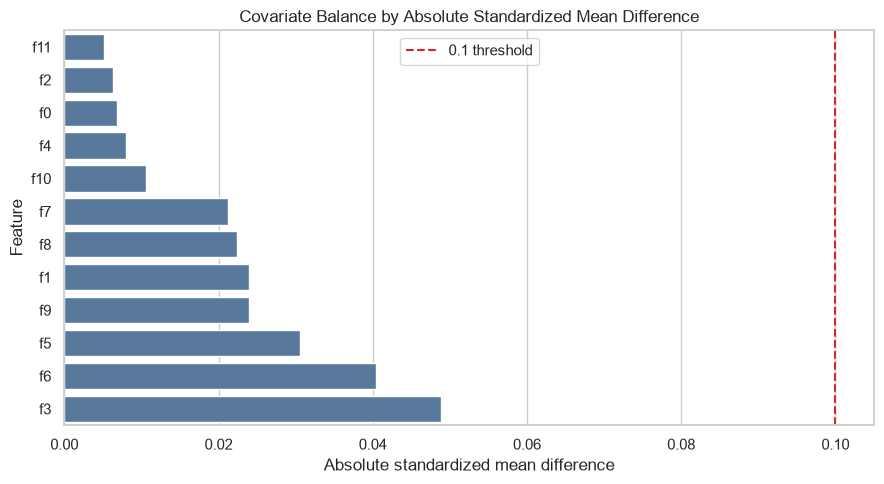

In [16]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=balance.sort_values("abs_smd", ascending=True),
    x="abs_smd",
    y="feature",
    color="#4C78A8",
)
plt.axvline(0.1, color="#D62728", linestyle="--", label="0.1 threshold")
plt.title("Covariate Balance by Absolute Standardized Mean Difference")
plt.xlabel("Absolute standardized mean difference")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()

### Interpretation
Treatment and control appear well balanced across the observed pre-treatment features. No features exceed the 0.1 standardized mean difference threshold, and most absolute SMD values are below 0.05.

This supports the validity of the randomized experiment and suggests that treatment assignment was not strongly correlated with observable user/context covariates. As a result, the experiment is suitable for Phase 2 heterogeneous treatment effect and uplift modeling.

## 6. Treatment Assignment vs Exposure

Important causal note: treatment assignment is randomized. Exposure may happen after assignment, so avoid treating exposure as if it were randomly assigned.

In [ ]:
con.sql(f"""
    select
        {TREATMENT_COL} as treatment,
        {EXPOSURE_COL} as exposure,
        count(*) as users,
        avg({OUTCOME_COL}) as conversion_rate,
        avg({VISIT_COL}) as visit_rate
    from experiment
    group by 1, 2
    order by 1, 2
""").df()

,treatment,exposure,users,conversion_rate,visit_rate
0,0,0,2096937,0.0019,0.0382
1,1,0,11454443,0.0012,0.0349
2,1,1,428212,0.0538,0.4145


## 7. Row-Level Sample for Lightweight Plots

Use the full dataset for aggregate SQL metrics. Use samples for row-level visualizations.

In [ ]:
sample_df = con.sql("""
    select *
    from experiment
    using sample 100000 rows
""").df()

sample_df.shape

(11882655, 16)

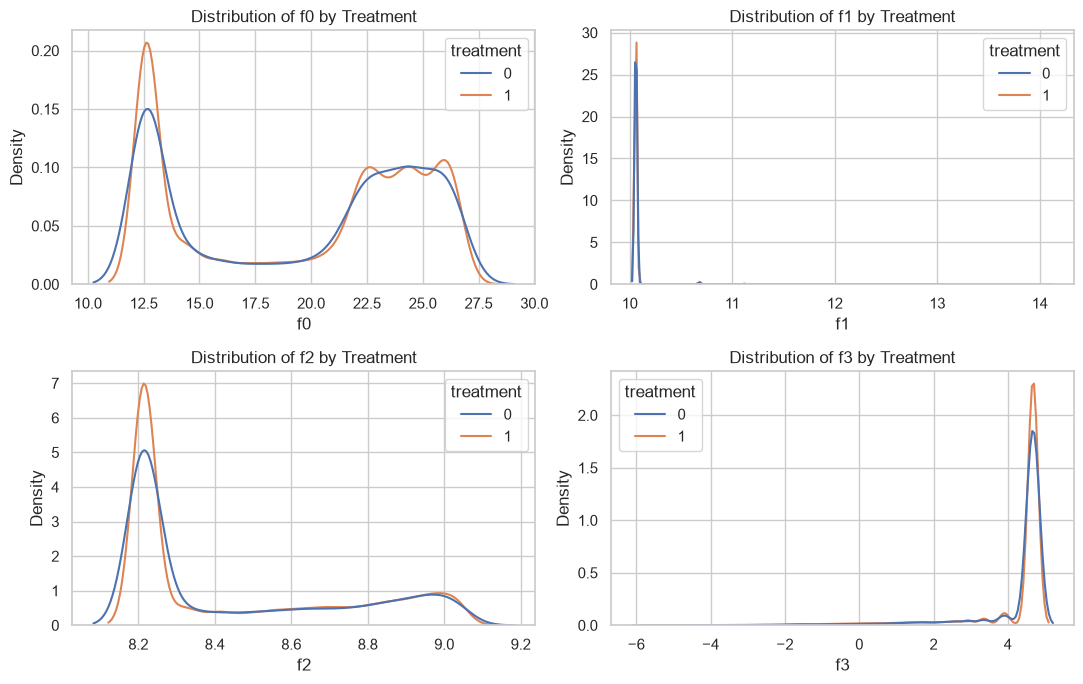

In [20]:
plot_features = feature_cols[:4]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for ax, col in zip(axes, plot_features):
    sns.kdeplot(
        data=sample_df,
        x=col,
        hue=TREATMENT_COL,
        common_norm=False,
        ax=ax,
    )
    ax.set_title(f"Distribution of {col} by Treatment")

plt.tight_layout()

## 8. Phase 1 Readout

- The experiment contains 137979592 users, with 11882655 assigned to treatment.
- Treatment conversion rate was 0.19 percentage points versus control conversion rate of 0.31 percentage points.
- The average treatment effect was 0.12 percentage points, or 59.45% relative lift.
- Covariate balance looked good, with max absolute SMD of 0.0488.
- Phase 1 conclusion: this experiment is suitable for heterogeneous treatment effect modeling.

Next step: build uplift models to estimate which users are persuadable, neutral, or negatively affected.